In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [11]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

In [12]:
# This figure uses two deposited tables
#
#   metadata_boxplot_data_all_figureS7_ptype_Sep2026.csv
#       gene set and per-gene metadata. The pausing index column
#       covers the untreated timepoint only.
#
#   Degron_PolII_pausing_ratio_with_metatadata_ENSGid.csv
#       the pausing-index pipeline output: the index at all three timepoints, which the
#       table above carries for the untreated timepoint only.
md = pd.read_csv("data/metadata_boxplot_data_all_figureS7_ptype_Sep2026.csv")
pau = pd.read_csv("data/Degron_PolII_pausing_ratio_with_metatadata_ENSGid.csv")

PI_COLS = {
    "D8L4Y_0h": "log2_pausing_ratio",
    "D8L4Y_90min": "log2_pausing_ratio_90min",
    "D8L4Y_8h": "log2_pausing_ratio_8h",
}

In [ ]:
# Filter the pausing index table to include only the gene set from the metadata table, using gene ids
pau["l2pi"] = np.log2(pau["pausing_ratio"].replace(0, np.nan))

wide = pau.pivot_table(index="gene_id", columns="condition", values="l2pi").rename(
    columns={
        "D8L4Y_0h": "log2_pausing_ratio",
        "D8L4Y_90min": "log2_pausing_ratio_90min",
        "D8L4Y_8h": "log2_pausing_ratio_8h",
    }
)
md = md.drop(columns=["log2_pausing_ratio"]).merge(
    wide[list(PI_COLS.values())], left_on="gene_id", right_index=True, how="left"
)

print(
    f"{md['log2_pausing_ratio'].notna().sum()} of {len(md)} genes have a 0 h pausing index"
)

9849 of 9860 genes have a 0 h pausing index


## Pol II occupancy filter

Genes are included where untreated cells show Pol II at the promoter, defined as TSS coverage more than 1.41-fold of mean upstream background, i.e. log2(TSS / upstream) > 0.5. The column ``TSS_cov_D8L4Y_0h`` is that value divided by the mean upstream signal, so the cutoff is applied directly as a fold.

In [ ]:
MIN_TSS_FOLD = (
    2**0.5
)  # log2(TSS / upstream) > 0.5; 0.32 RPKM at the 0 h background of 0.2262

before = md["log2_pausing_ratio"].notna().sum()
md = md[md["TSS_cov_D8L4Y_0h"].notna() & (md["TSS_cov_D8L4Y_0h"] > MIN_TSS_FOLD)]
after = md["log2_pausing_ratio"].notna().sum()
print(
    f"occupancy filter (log2 fold > 0.5, i.e. > {MIN_TSS_FOLD:.3f}x background): "
    f"{before} -> {after} genes ({before - after} removed)"
)

occupancy filter (log2 fold > 0.5, i.e. > 1.414x background): 9307 -> 9307 genes (0 removed)


In [ ]:
# Long format for the ECDF, one row per gene x timepoint.
# No additional coverage filter: the gene set is the one fixed upstream in the S7 table.
pausing_ratio = (
    pd.concat(
        [
            md[["gene_id", col]]
            .rename(columns={col: "log2_pausing_ratio"})
            .assign(condition=cond)
            for cond, col in PI_COLS.items()
        ],
        ignore_index=True,
    )
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["log2_pausing_ratio"])
)

pausing_ratio.groupby("condition").size()

condition
D8L4Y_0h       9307
D8L4Y_8h       9307
D8L4Y_90min    9307
dtype: int64

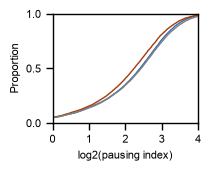

In [17]:
# plot ECDF of log2 pausing index for manuscript
sns.set_context("paper")

pal = sns.color_palette(["grey", "xkcd:rust", "xkcd:medium blue"])
condition_order = ["D8L4Y_0h", "D8L4Y_90min", "D8L4Y_8h"]

f, a = plt.subplots(figsize=(4, 1.8))

sns.ecdfplot(
    pausing_ratio,
    x="log2_pausing_ratio",
    hue="condition",
    hue_order=condition_order,
    palette=pal,
    linewidth=1,
    legend=False,
    ax=a,
)

a.set_box_aspect(0.75)

# The ECDF is computed over every gene in the table; the x-range below is a view,
# not a filter, so the curves do not start at zero. See the note printed in the next cell.
a.set_xlim(0, 4)
a.set_xlabel("log2(pausing index)", fontsize=8)

a.set_ylabel("Proportion", fontsize=8)
a.set_yticks([0, 0.5, 1])

a.tick_params(axis="both", labelsize=8)

f.tight_layout()

f.savefig("pausing_ratio_ECDF_0_1p5_8hr.svg")

In [ ]:
# Proportion of each curve that lies left of the plotted range, i.e. the height at x = 0.
for cond in condition_order:
    v = pausing_ratio.query("condition == @cond").log2_pausing_ratio
    print(
        f"{cond:<12} n = {len(v):>5}   fraction with log2 pausing index <= 0: {(v <= 0).mean():.3f}"
    )

D8L4Y_0h     n =  9307   fraction with log2 pausing index <= 0: 0.047
D8L4Y_90min  n =  9307   fraction with log2 pausing index <= 0: 0.051
D8L4Y_8h     n =  9307   fraction with log2 pausing index <= 0: 0.050


In [ ]:
# Fraction of genes above the highly-paused threshold quoted in the Results.
above_4 = pausing_ratio.query("condition == 'D8L4Y_0h' & log2_pausing_ratio > 4")
all_0h = pausing_ratio.query("condition == 'D8L4Y_0h'")
print(
    f"{above_4.shape[0]} / {all_0h.shape[0]} = {above_4.shape[0] / all_0h.shape[0]:.2%}"
)

210 / 9307 = 2.26%
